# Causal Inference
## Задание CI.5


**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту `@miptstats_ds24_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив ее как файл боту вместе с ноутбуком *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $\LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

---


**Баллы за задание:**

* Задача 1 — 100 баллов
* Задача 2 — 100 баллов

In [1]:
# Bot check

# HW_ID: ds_ci5
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
!pip install causalml --quiet
!pip install dowhy --quiet
!pip install dowhy[extras] --quiet
!pip install econml --quiet
!pip install scikit-uplift --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [3]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostRegressor
import statsmodels.formula.api as smf

from causalml.dataset import make_uplift_classification
from causalml.inference.tree import (
    UpliftTreeClassifier,
    UpliftRandomForestClassifier,
)
from causalml.inference.tree import uplift_tree_string, uplift_tree_plot
from IPython.display import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics.pairwise import rbf_kernel
from tqdm.notebook import tqdm

from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

import dowhy
from dowhy import CausalModel

from joblib import Parallel, delayed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(123)
sns.set(font_scale=1.3, palette="Set2")

Failed to import duecredit due to No module named 'duecredit'


---
### Задача 1.

Напишите реализацию нейронной сети DragonNet с регуляризацией. Предусмотрите три варианта лосса:
* простой без регуляризации,
* с регуляризацией,
* в версии BCAUSS.

In [4]:
class EpsilonLayer(nn.Module):
    def __init__(self):
        super(EpsilonLayer, self).__init__()
        # Единственный обучаемый параметр
        self.epsilon = nn.Parameter(torch.zeros(1))

    def forward(self, t_pred):
        return self.epsilon * torch.ones_like(t_pred)

class DragonNet(nn.Module):
    def __init__(self,
                 input_dim,
                 neurons_per_layer=200,
                 reg_l2=0.01):
        super(DragonNet, self).__init__()
        self.reg_neurons = neurons_per_layer
        self.reg_l2 = reg_l2

        self.shared = nn.Sequential(
            nn.Linear(input_dim, neurons_per_layer),
            nn.ELU(),
            nn.Linear(neurons_per_layer, neurons_per_layer),
            nn.ELU(),
            nn.Linear(neurons_per_layer, neurons_per_layer),
            nn.ELU(),
        )

        self.propensity_head = nn.Sequential(
            nn.Linear(neurons_per_layer, 1),
            nn.Sigmoid()
        )
        hidden_size = neurons_per_layer // 2
        self.y0_net = nn.Sequential(
            nn.Linear(neurons_per_layer, hidden_size),
            nn.ELU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ELU(),
            nn.Linear(hidden_size, 1)
        )
        self.y1_net = nn.Sequential(
            nn.Linear(neurons_per_layer, hidden_size),
            nn.ELU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ELU(),
            nn.Linear(hidden_size, 1)
        )
        self.epsilon_layer = EpsilonLayer()

    def forward(self, x):
        z = self.shared(x)
        t_pred = self.propensity_head(z).clamp(1e-6,1-1e-6)
        y0 = self.y0_net(z)
        y1 = self.y1_net(z)
        eps = self.epsilon_layer(t_pred)
        out = torch.cat([y0, y1, t_pred, eps], dim=1)
        return out, z

In [5]:
def dragonnet_loss_regularized(output, t_true, y_true, alpha=1.0, beta=0.0):
    y0_pred, y1_pred, t_pred, eps = torch.chunk(output, 4, dim=1)

    mse_factual = torch.where(
        t_true == 1,
        (y_true - y1_pred).pow(2),
        (y_true - y0_pred).pow(2)
    ).mean()

    bce_prop = F.binary_cross_entropy(t_pred, t_true)

    Q_est = torch.where(t_true == 1, y1_pred, y0_pred) + \
            eps * (t_true / t_pred - (1 - t_true) / (1 - t_pred))

    gamma = (Q_est - y_true).pow(2).mean()

    return mse_factual + alpha * bce_prop + beta * gamma


In [6]:
def dragonnet_loss_bcauss(output, z, t_true, y_true,
                          alpha=1.0,    # вес BCE_prop
                          beta=0.0,     # вес таргетед‑рег.
                          lamb=1.0,     # вес MMD‑term
                          sigma=1.0):   # RBF‑ширина
    """
    Args:
        output: Tensor (batch,4)  = [y0, y1, t_pred, eps]
        z:      Tensor (batch, hid) — shared representation
        t_true: Tensor (batch,1)
        y_true: Tensor (batch,1)
        alpha:  вес для propensity‑BCE
        beta:   вес для ε‑регуляризации
        lamb:   вес для MMD imbalance penalty
        sigma:  RBF‑kernel width
    """
    # распакуем предсказания
    y0_pred, y1_pred, t_pred, eps = torch.chunk(output, 4, dim=1)

    # 1) factual MSE
    mse_f = torch.where(t_true == 1,
                        (y_true - y1_pred).pow(2),
                        (y_true - y0_pred).pow(2)).mean()

    # 2) propensity BCE
    bce_p = F.binary_cross_entropy(t_pred, t_true)

    # 3) targeted adjustment
    Q_est = torch.where(t_true == 1, y1_pred, y0_pred) + \
            eps * (t_true / t_pred - (1 - t_true) / (1 - t_pred))
    targ = (Q_est - y_true).pow(2).mean()

    # 4) imbalance penalty через RBF‑MMD на z
    mask = t_true.view(-1)==1
    z1, z0 = z[mask], z[~mask]
    if len(z1)>1 and len(z0)>1:
        gamma = 1/(2*sigma**2)
        K11 = rbf_kernel(z1.cpu().detach(), z1.cpu().detach(), gamma=gamma)
        K00 = rbf_kernel(z0.cpu().detach(), z0.cpu().detach(), gamma=gamma)
        K10 = rbf_kernel(z1.cpu().detach(), z0.cpu().detach(), gamma=gamma)
        mmd_value = K11.mean() + K00.mean() - 2 * K10.mean()
        mmd_pen = torch.tensor(mmd_value, device=z.device, dtype=z.dtype)
    else:
        mmd_pen = torch.tensor(0., device=z.device)

    return mse_f + alpha*bce_p + beta*targ + lamb*mmd_pen

In [7]:
def estimate_cate(model, X, device=None):
    """
    Оценивает CATE по обученной модели DragonNet.

    Аргументы:
        model: обученная модель DragonNet
        X: np.ndarray или torch.Tensor, shape (n_samples, input_dim)
        device: torch.device, устройство (cpu или cuda), по умолчанию autodetect

    Возвращает:
        cate: np.ndarray, оценки CATE для каждого объекта
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model.eval()

    if isinstance(X, np.ndarray):
        X = torch.tensor(X, dtype=torch.float32)
    X = X.to(device)

    with torch.no_grad():
        output, _ = model(X)
        y0_pred, y1_pred, _, _ = torch.chunk(output, 4, dim=1)
        cate = (y1_pred - y0_pred).squeeze(1).cpu().numpy()

    return cate

In [8]:
def train_dragonnet(
    model,
    X,
    t,
    y,
    epochs=10,
    batch_size=64,
    lr=1e-3,
    alpha=1.0,
    beta=0.1,
    weight_decay=0.0,
    use_bcauss=False,
    verbose=True,
    device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Перемещение данных на нужное устройство
    X = torch.tensor(X, dtype=torch.float32).to(device)
    t = torch.tensor(t, dtype=torch.float32).to(device)
    y = torch.tensor(y, dtype=torch.float32).to(device)

    dataset = TensorDataset(X, t, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = model.to(device)
    model.train()

    optimizer = torch.optim.AdamW(
        model.parameters(), weight_decay=weight_decay
    )

    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for Xb, tb, yb in loader:
            Xb, tb, yb = Xb.to(device), tb.to(device), yb.to(device)
            optimizer.zero_grad()
            out, z = model(Xb)

            if use_bcauss:
                loss = dragonnet_loss_bcauss(
                    out, z, tb.unsqueeze(1), yb.unsqueeze(1), alpha, beta
                )
            else:
                loss = dragonnet_loss_regularized(
                    out, tb.unsqueeze(1), yb.unsqueeze(1), alpha, beta
                )

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * Xb.size(0)

        avg_loss = total_loss / len(loader.dataset)
        if verbose:
            print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.4f}")


Для проверки модели возьмем полусинтетические данные IHDP (Infant Health and Development Program), которые можно скачать по ссылкам: <a href="https://www.fredjo.com/files/ihdp_npci_1-1000.train.npz.zip">трейн</a>, <a href="https://www.fredjo.com/files/ihdp_npci_1-1000.test.npz.zip">тест</a>.

Каждый файл является numpy-архивом, который считывается следующим образом

In [10]:
data = np.load('ihdp_npci_1-1000.train.npz')
data.files

['ate', 'mu1', 'mu0', 'yadd', 'yf', 'ycf', 't', 'x', 'ymul']

Значения файлов:
* `x` &mdash; признаки (ковариаты, конфаундеры);
* `t` &mdash; тритмент;
* `yf` &mdash; фактические исходы (таргет);
* `ycf` &mdash; контрафактивные исходы;
* `mu0, mu1` &mdash; потенциальные исходы до зашумления.

Значения каждого отдельного файла можно получить, вызвав его по имени подобно словарю.

Например, вот истинный теоретический причинно-следственный эффект

In [11]:
data['ate']

array(4)

Обучающий набор содержит 1000 датасетов по 672 объекта в каждом

In [12]:
data['x'].shape, data['t'].shape, data['yf'].shape

Посчитайте истинную ATE отдельно для каждого датасета. Это можно сделать потому как в этом синтетическом датасете мы знаем контрафактивные исходы. Далее будем сравнивать оценку модели именно с этими значениями, а не с теоретическим значением `data['ate']`.

In [13]:
t = data["t"]
yf = data["yf"]

mask1 = (t == 1)
mask0 = (t == 0)

yf_treated = np.where(mask1, yf, np.nan)
yf_control = np.where(mask0, yf, np.nan)

ate_arr = np.nanmean(yf_treated, axis=0) - np.nanmean(yf_control, axis=0)
ate_arr[:20]

array([ 4.06758412,  4.07072988,  4.24085609,  4.26064113,  4.19503976,
        4.10091248,  3.82396262,  3.68045533, 11.79094366,  5.14570211,
        3.99576838,  4.06415704, 14.57241386,  3.76836104,  4.07273311,
        4.90318888,  3.61038455,  3.59996573,  4.05260208,  4.38298362])

In [16]:
yf = data['yf']
ycf = data['ycf']
t = data['t']

y0 = np.where(t == 0, yf, ycf)
y1 = np.where(t == 1, yf, ycf)

true_ate = (y1 - y0).mean(axis=0)

print(true_ate[:20])

[ 4.03331693  4.04179142  4.12732522  4.19891722  4.14814148  4.06404961
  3.89777774  3.86681137 10.17937455  4.83428138  3.81900543  4.10818882
 12.4234167   3.85531954  3.91927512  4.56450569  3.6612902   3.73694132
  3.99313794  4.2033221 ]


In [15]:
abort()

NameError: name 'abort' is not defined

Для каждого из 1000 датасетов 
* обучите модель с регуляризацией и без нее,
* обучите модель с лоссом BCAUSS,
* посчитайте оценки ATE.

По результатам посчитайте метрики RMSE и MAE.

In [ ]:
def write_metrics(ates, pred_ates, df, row_name):
    rmse_result = rmse(ates, pred_ates)
    mae_result = mae(ates, pred_ates)

    df.loc[row_name, 'rmse'] = rmse_result
    df.loc[row_name, 'mae'] = mae_result
    return df
result_df = pd.DataFrame()

In [ ]:
# N = 10
N = data["x"].shape[2]

1. Без регуляризации

In [ ]:
predicted_ates = []

for i in tqdm(range(N)):
    model = DragonNet(input_dim=data["x"].shape[1])
    X = data["x"][:, :, i]
    t = data["t"][:, i]
    y = data["yf"][:, i]
    batch_size = min(1024, len(X))
    train_dragonnet(
        model,
        X,
        t,
        y,
        epochs=30,                  
        batch_size=batch_size,       
        lr=2e-3,                     
        alpha=0.25,                     
        beta=0,                      
        weight_decay=0.01,           
        use_bcauss=False,             
        verbose=False,                
        device=device
    )
    ate = np.mean(estimate_cate(model, X, device = device))
    predicted_ates.append(ate)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
write_metrics(ate_arr[:N], predicted_ates[:N], result_df, "Без регуляризации")

,rmse,mae
Без регуляризации,1.821548,1.243646


2. Добавим регуляризацию

In [ ]:
predicted_ates = []

for i in tqdm(range(N)):
    model = DragonNet(input_dim=data["x"].shape[1])
    X = data["x"][:, :, i]
    t = data["t"][:, i]
    y = data["yf"][:, i]
    batch_size = min(1024, len(X))
    train_dragonnet(
        model,
        X,
        t,
        y,
        epochs=30,                  
        batch_size=batch_size,       
        lr=2e-3,                     
        alpha=0.25,                     
        beta=0.5,                      
        weight_decay=0.01,           
        use_bcauss=False,             
        verbose=False,                
        device=device
    )
    ate = np.mean(estimate_cate(model, X, device = device))
    predicted_ates.append(ate)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
write_metrics(ate_arr[:N], predicted_ates[:N], result_df, "Регуляризации, beta=0.5")

,rmse,mae
Без регуляризации,1.821548,1.243646
"Регуляризации, beta=0.5",1.847214,1.170211


3. Применим BCAUSS

In [ ]:
predicted_ates = []

for i in tqdm(range(N)):
    model = DragonNet(input_dim=data["x"].shape[1])
    X = data["x"][:, :, i]
    t = data["t"][:, i]
    y = data["yf"][:, i]
    batch_size = min(1024, len(X))
    train_dragonnet(
        model,
        X,
        t,
        y,
        epochs=30,                  
        batch_size=batch_size,       
        lr=2e-3,                     
        alpha=0.25,                     
        beta=0.5,                      
        weight_decay=0.01,           
        use_bcauss=True,             
        verbose=False,                
        device=device
    )
    ate = np.mean(estimate_cate(model, X, device=device))
    predicted_ates.append(ate)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
write_metrics(ate_arr[:N], predicted_ates[:N], result_df, "BCAUSS")

,rmse,mae
Без регуляризации,1.821548,1.243646
"Регуляризации, beta=0.5",1.847214,1.170211
BCAUSS,1.973878,1.201256


Для некоторых датасетов сравните визуально гистограммы propensity score и balancing score.

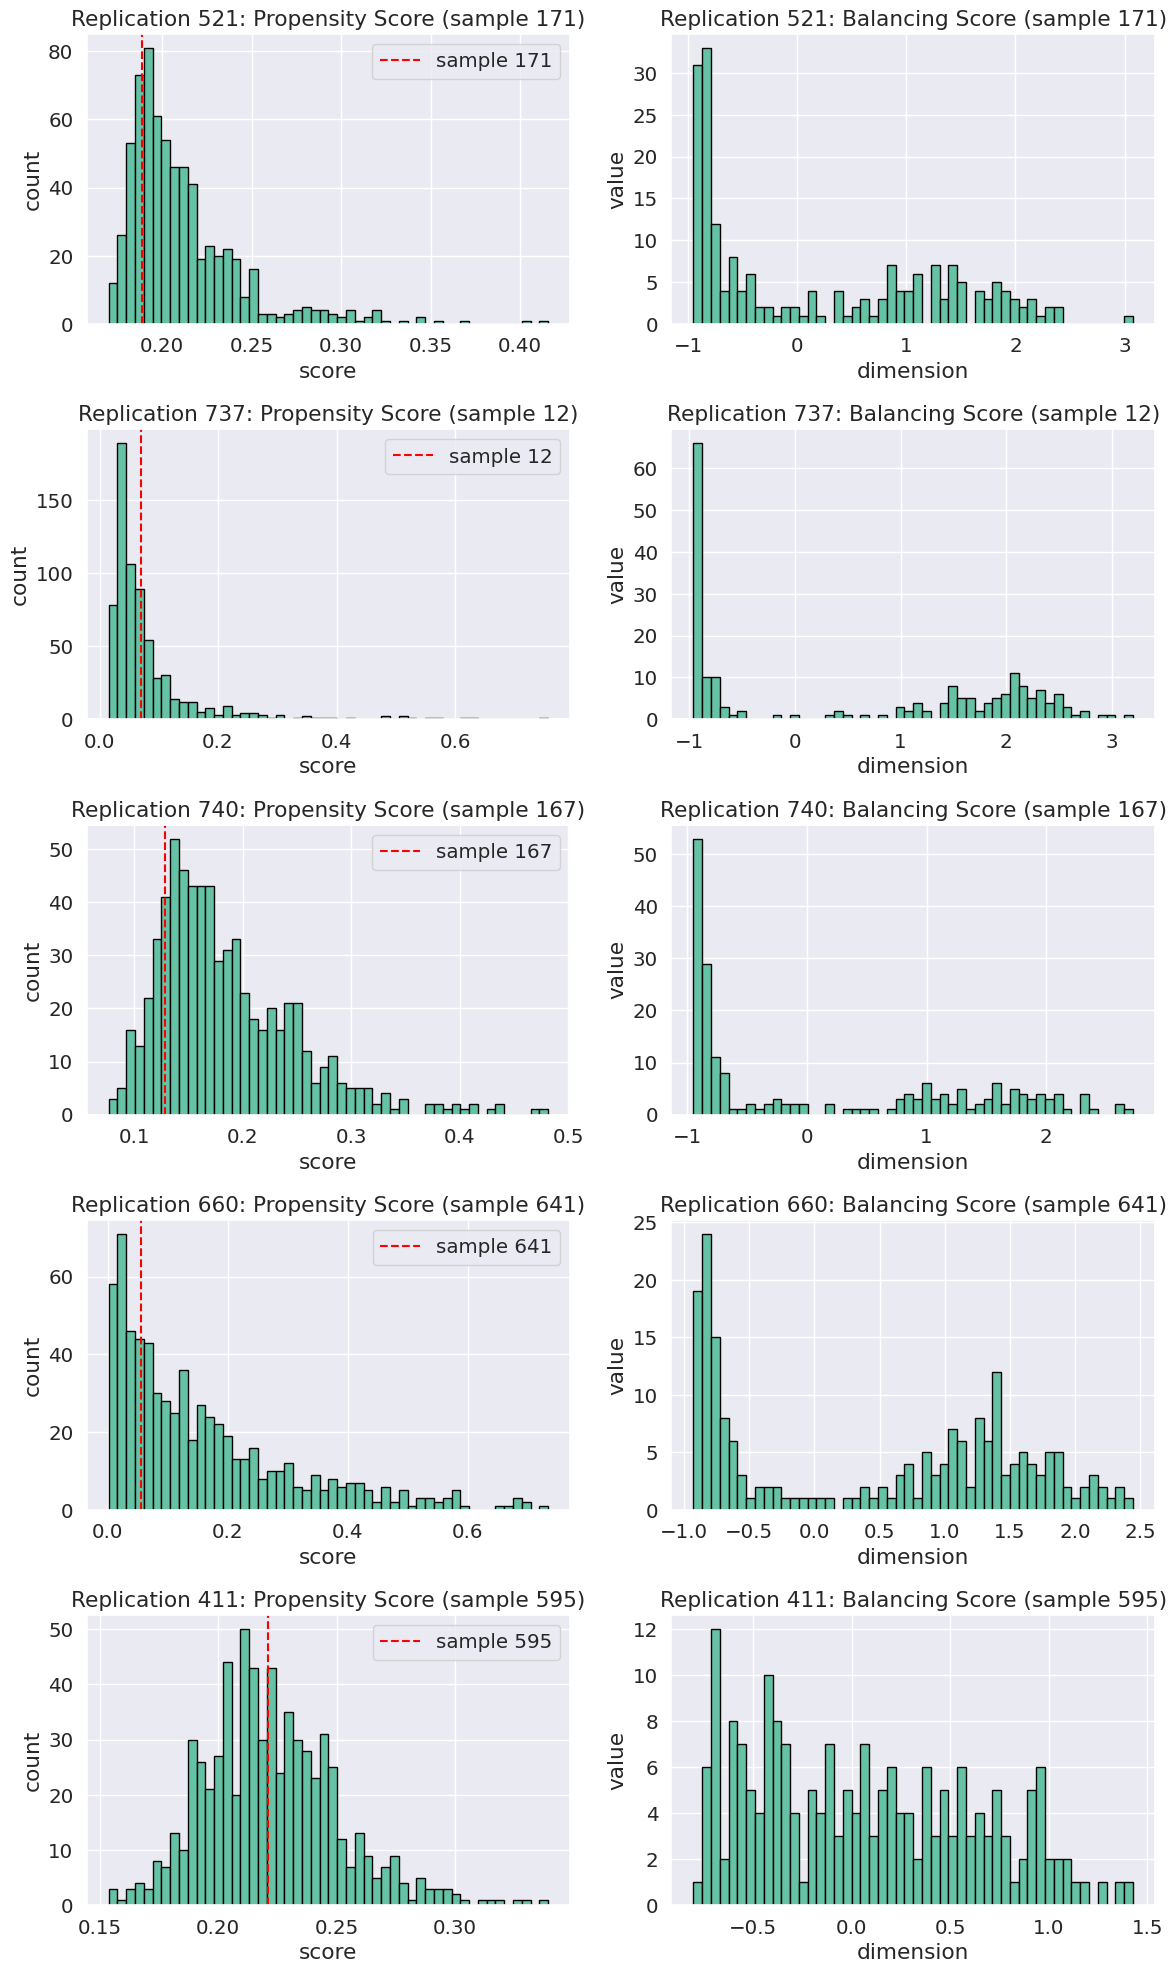

In [ ]:
np.random.seed(42)
replication_indices = np.random.choice(data['x'].shape[2], size=5, replace=False)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))

for i, j in enumerate(replication_indices):
    # Данные для одной репликации
    X = data['x'][:, :, j]
    t = data['t'][:, j]
    y = data['yf'][:, j]
    batch_size = min(1024, len(X))

    # Инициализация модели
    model = DragonNet(input_dim=data["x"].shape[1])
    train_dragonnet(
        model,
        X,
        t,
        y,
        epochs=30,
        batch_size=batch_size,
        lr=1e-3,
        alpha=1.0,
        beta=1,
        weight_decay=1e-3,
        use_bcauss=True,
        verbose=False,
        device=device
    )

    # Прогон модели на обучающей выборке
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    out, z = model(X_tensor)
    propensity_score = torch.chunk(out, 4, dim=1)[2].detach().cpu().numpy()
    z = z.detach().cpu().numpy()

    # Случайный индекс наблюдения внутри текущей репликации
    sample_idx = np.random.choice(len(X))

    # Гистограмма propensity score с вертикальной линией для sample_idx
    axes[i, 0].hist(propensity_score, bins=50, edgecolor='black')
    axes[i, 0].axvline(propensity_score[sample_idx], color='red', linestyle='--', label=f"sample {sample_idx}")
    axes[i, 0].set_title(f'Replication {j}: Propensity Score (sample {sample_idx})')
    axes[i, 0].set_xlabel('score')
    axes[i, 0].set_ylabel('count')
    axes[i, 0].legend()

    # Вектор balancing score для того же sample_idx
    axes[i, 1].hist(z[sample_idx], bins=50, edgecolor='black')
    axes[i, 1].set_title(f'Replication {j}: Balancing Score (sample {sample_idx})')
    axes[i, 1].set_xlabel('dimension')
    axes[i, 1].set_ylabel('value')

plt.tight_layout()
plt.show()

Проведите аналогичные действия с моделями
* линейная регрессия,
* propensity score weighting,
* doubly robust estimation.

Можно использовать как реализации из обучающих ноутбуков, так и библиотечные.

Сравните результат с DragonNet.

1. Линейная регрессия.

In [ ]:
N = 300

def compute_ate(i, X, t, yf):
    """Вычисляет ATE для одной итерации."""
    df = pd.DataFrame(X[:, :, i], columns=[f'x{j}' for j in range(X.shape[1])])
    df["treatment"] = t[:, i]
    df["outcome"] = yf[:, i]

    # Инициализация модели (можно вынести наружу, если параметры фиксированы)
    model = CausalModel(
        data=df,
        treatment="treatment",
        outcome="outcome",
        common_causes=[f'x{j}' for j in range(X.shape[1])]
    )
    
    # Идентификация и оценка
    identified_estimand = model.identify_effect()
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"  # Можно заменить на более быстрый метод
    )
    return estimate.value

# Предварительная загрузка данных в numpy (если они еще не в numpy)
X = np.asarray(data["x"])
t = np.asarray(data["t"])
yf = np.asarray(data["yf"])

# Параллельный расчет ATE
predicted_ates = Parallel(n_jobs=-1)(
    delayed(compute_ate)(i, X, t, yf)
    for i in tqdm(range(N)))

  0%|          | 0/300 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFra

In [ ]:
write_metrics(ate_arr[:N], predicted_ates[:N], result_df, "Линейная регрессия")

,rmse,mae
Без регуляризации,1.821548,1.243646
"Регуляризации, beta=0.5",1.847214,1.170211
BCAUSS,1.973878,1.201256
Линейная регрессия,1.908633,0.977088


2. Propensity score weighting

In [ ]:
def process_iteration(i, data):
    X_i = data["x"][:, :, i]
    t_i = data["t"][:, i]
    y_i = data["yf"][:, i]

    df = pd.DataFrame(X_i, columns=[f"x{j}" for j in range(X_i.shape[1])])
    df["treatment"] = t_i
    df["outcome"] = y_i

    # Propensity score model (ускоренная версия)
    log_reg = LogisticRegression(max_iter=1000, solver="lbfgs")
    log_reg.fit(df.filter(like="x"), df["treatment"])
    propensity_scores = log_reg.predict_proba(df.filter(like="x"))[:, 1]

    # Рассчет весов
    treated = df["treatment"] == 1
    df["weights"] = np.where(
        treated, 1 / propensity_scores, 1 / (1 - propensity_scores)
    )

    # Causal model
    model = CausalModel(
        data=df,
        treatment="treatment",
        outcome="outcome",
        common_causes=[f"x{j}" for j in range(X_i.shape[1])],
        weights="weights",
    )

    # Правильный метод оценки
    identified_estimand = model.identify_effect()
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_weighting",
    )

    return estimate.value


# Конвертируем данные в numpy для ускорения
data_np = {
    "x": np.asarray(data["x"]),
    "t": np.asarray(data["t"]),
    "yf": np.asarray(data["yf"]),
}

# Параллельный расчет
predicted_ates = Parallel(n_jobs=-1)(
    delayed(process_iteration)(i, data_np) for i in tqdm(range(N))
)

  0%|          | 0/300 [00:00<?, ?it/s]

In [ ]:
write_metrics(ate_arr[:N], predicted_ates[:N], result_df, "Propensity score weighting")

,rmse,mae
Без регуляризации,1.821548,1.243646
"Регуляризации, beta=0.5",1.847214,1.170211
BCAUSS,1.973878,1.201256
Линейная регрессия,1.908633,0.977088
Propensity score weighting,0.489099,0.275686


3. Doubly robust estimation

In [ ]:
def process_iteration(i, data):
    X_i = data["x"][:, :, i]
    t_i = data["t"][:, i]
    y_i = data["yf"][:, i]
    
    df = pd.DataFrame(X_i, columns=[f"x{j}" for j in range(X_i.shape[1])])
    df["treatment"] = t_i
    df["outcome"] = y_i

    # Инициализация причинной модели
    model = CausalModel(
        data=df,
        treatment="treatment",
        outcome="outcome",
        common_causes=[f"x{j}" for j in range(X_i.shape[1])]
    )
    
    # Идентификация эффекта
    identified_estimand = model.identify_effect()

    # Doubly Robust Estimation с использованием EconML
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.econml.dr.LinearDRLearner",
        control_value=0,
        treatment_value=1,
        method_params={
            "init_params": {
                "model_propensity": LogisticRegression(max_iter=1000),
                "model_regression": LinearRegression(),
                "cv": 3  # Кросс-валидация
            },
            "fit_params": {}
        }
    )
    
    return estimate.value

# Конвертация данных в numpy массивы
data_np = {
    "x": np.asarray(data["x"]),
    "t": np.asarray(data["t"]),
    "yf": np.asarray(data["yf"]),
}

# Параллельный расчет
predicted_ates = Parallel(n_jobs=-1)(
    delayed(process_iteration)(i, data_np) for i in tqdm(range(N))
)

  0%|          | 0/300 [00:00<?, ?it/s]

In [ ]:
write_metrics(ate_arr[:N], predicted_ates[:N], result_df, "Doubly robust estimation")

,rmse,mae
Без регуляризации,1.821548,1.243646
"Регуляризации, beta=0.5",1.847214,1.170211
BCAUSS,1.973878,1.201256
Линейная регрессия,1.908633,0.977088
Propensity score weighting,0.489099,0.275686
Doubly robust estimation,0.926220,0.500679


Сделайте выводы.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, KFold

from sklift.datasets.datasets import fetch_x5
from sklift.metrics import uplift_at_k, uplift_by_percentile
from sklift.models import SoloModel, TwoModels, ClassTransformation
# from sklift.viz import plot_uplift_preds, plot_uplift_by_percentile, plot_qini_curve, plot_uplift_curve

sns.set(style='whitegrid', font_scale=1.5, palette='Set2')
pd.set_option('display.max_columns', None)

---
### Задача 2.

На занятии мы посмотрели работу простых моделей на данных <a href="https://ods.ai/competitions/x5-retailhero-uplift-modeling">конкурса X5 Retail Hero</a>. Напомним, требуется построить модель, определяющую клиентов, которым стоит отправлять смс. Отметим, что в данном случае нам не требуется как можно точнее оценить CATE, требуется скорее определить степерь уверенности того, что клиент совершит покупку из-за получения смс, или наоборот.

Стандартные способы загрузки данных:
1. непосредственно со <a href="https://ods.ai/competitions/x5-retailhero-uplift-modeling">страницы конкура</a>;
2. вызовом <a href="https://www.uplift-modeling.com/en/latest/api/datasets/fetch_x5.html">`data = sklift.datasets.fetch_x5()`</a>

**Но прежде всего обратите внимание, что данные большие, и все целиком они могут не вместиться даже в достаточно большую оперативку, например, в Colab не помещаются.** Поэтому мы подготовили для вас сжатый формат данных, которые вы можете скачать по ссылкам ниже.
1. Данные о <a href="https://disk.yandex.ru/d/ZxtypOGcVm9ibw">клиентах</a>, <a href="https://disk.yandex.ru/d/b9czlSQeLAU0dw">тритменте и таргете</a>, все в исходном формате.
2. <a href="https://disk.yandex.ru/d/BvDtDzV_4rJfDg">Сгруппированные данные по покупкам</a>, то есть для каждой покупки оставляется только информация о сумме покупке, количеству уникальных позиций.
3. Те же сгруппированные данные, но <a href="https://disk.yandex.ru/d/gQn1zn6PBHkzXA">разделенные случайно на 10 частей</a>.
3. Полные данные, <a href="https://disk.yandex.ru/d/gDFMnY2PkpsX3g">разделенные случайно на 50 частей</a>. Каждый клиент присутствует только в одной части.

*Рекомендация.* Начинайте с небольших данных, для отладки кода выделяйте небольшое количество клиентов. Переходите к большему объему данных только после того, как построете хорошие модели на меньшем объеме. Сохраняйте рабочие версии на случай если что-то случайно испортить.

In [ ]:
data_clients = pd.read_csv('/kaggle/input/ci-5-hw/retailhero-uplift/data/clients.csv', index_col=0)
data_clients.head()

,first_issue_date,first_redeem_date,age,gender
client_id,,,,
000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U
000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F
000048b7a6,2018-12-15 13:33:11,NaN,68,F
000073194a,2017-05-23 12:56:14,2017-11-24 11:18:01,60,F
00007c7133,2017-05-22 16:17:08,2018-12-31 17:17:33,67,U


In [ ]:
data_train = pd.read_csv('/kaggle/input/ci-5-hw/retailhero-uplift/data/uplift_train.csv', index_col=0)
data_train.sample(10)

,treatment_flg,target
client_id,,
4a950d7807,0,1
3f37cc2bfa,0,1
051c0de516,1,0
8c3e064890,0,1
e641304350,1,0
bc7ac00508,0,1
dafe8b05bb,1,1
ea1c6cd92e,0,1
4c19d250fa,0,0


In [ ]:
data_purchases = pd.read_csv('/kaggle/input/ci-5-hw/retailhero-uplift/data/purchases.csv', index_col=0)

In [ ]:
data_purchases['transaction_datetime'] = pd.to_datetime(data_purchases['transaction_datetime'])

data_purchases = data_purchases[['transaction_datetime', 'purchase_sum']].copy()
data_purchases = data_purchases.drop_duplicates()
data_purchases.head()

,transaction_datetime,purchase_sum
client_id,,
000012768d,2018-12-01 07:12:45,1007.0
000012768d,2018-12-16 08:56:01,574.0
000012768d,2019-03-08 10:12:03,803.0
000012768d,2019-03-14 15:01:47,419.0
000036f903,2018-11-28 10:48:36,241.0


Оставим только общую покупку за месяц

In [ ]:
data_purchases = data_purchases.copy()
data_purchases['month'] = data_purchases['transaction_datetime'].dt.to_period('M').dt.to_timestamp()

monthly_sum = (
    data_purchases
    .groupby(['client_id', 'month'])['purchase_sum']
    .sum()
    .reset_index()
)

monthly_sum.rename(columns={'month': 'transaction_month'}, inplace=True)

In [ ]:
monthly_sum.head()

,client_id,transaction_month,purchase_sum
0,000012768d,2018-12-01,1581.0
1,000012768d,2019-03-01,1222.0
2,000036f903,2018-11-01,241.0
3,000036f903,2018-12-01,3343.0
4,000036f903,2019-01-01,1784.0


In [ ]:
df_features = data_clients.copy()

df_features['first_issue_time'] = \
    (pd.to_datetime(df_features['first_issue_date'])
     - pd.Timestamp('1970-01-01')) // pd.Timedelta('1s')
df_features['first_redeem_time'] = \
    (pd.to_datetime(df_features['first_redeem_date'])
     - pd.Timestamp('1970-01-01')) // pd.Timedelta('1s')

df_features['issue_redeem_delay'] = df_features['first_redeem_time'] - df_features['first_issue_time']

df_features = df_features.drop(['first_issue_date', 'first_redeem_date'], axis=1)

df_features.head()

,age,gender,first_issue_time,first_redeem_time,issue_redeem_delay
client_id,,,,,
000012768d,45,U,1501947648,1.515094e+09,13146559.0
000036f903,72,F,1491832463,1.492951e+09,1118613.0
000048b7a6,68,F,1544880791,NaN,NaN
000073194a,60,F,1495544174,1.511522e+09,15978107.0
00007c7133,67,U,1495469828,1.546277e+09,50806825.0


In [ ]:
monthly_wide = (
    monthly_sum
    .pivot(index='client_id', columns='transaction_month', values='purchase_sum')
)

# Объединяем с df_features по индексу client_id
df_features_extended = df_features.join(monthly_wide, how='left')

def rename_date_columns(df):
    new_columns = []
    for col in df.columns:
        try:
            # Пробуем преобразовать в дату
            month_name = pd.to_datetime(col).strftime('%Y-%m')
            new_columns.append(month_name)
        except:
            # Если не дата, оставляем как есть
            new_columns.append(col)
    df.columns = new_columns
    return df

# Применяем функцию к вашему DataFrame
df_features_extended = rename_date_columns(df_features_extended.copy())
df_features_extended.fillna(0, inplace=True)

df_features_extended.head()

,age,gender,first_issue_time,first_redeem_time,issue_redeem_delay,2018-11,2018-12,2019-01,2019-02,2019-03
client_id,,,,,,,,,,
000012768d,45,U,1501947648,1.515094e+09,13146559.0,0.0,1581.00,0.00,0.00,1222.00
000036f903,72,F,1491832463,1.492951e+09,1118613.0,241.0,3343.00,1784.00,3166.00,1271.00
000048b7a6,68,F,1544880791,0.000000e+00,0.0,0.0,445.00,1962.00,1023.00,342.00
000073194a,60,F,1495544174,1.511522e+09,15978107.0,479.0,745.16,4153.87,3636.40,586.97
00007c7133,67,U,1495469828,1.546277e+09,50806825.0,319.0,3840.00,760.00,1420.84,380.00


In [ ]:
df_features = df_features_extended.copy()
gender_map = {'F': 0, 'M': 1, 'U': 2}
df_features["gender"] = df_features["gender"].map(gender_map)

In [ ]:
indices_learn, indices_valid = train_test_split(data_train.index, test_size=0.3, random_state=123)

X_train = df_features.loc[indices_learn, :]
y_train = data_train.loc[indices_learn, 'target']
treat_train = data_train.loc[indices_learn, 'treatment_flg']

X_val = df_features.loc[indices_valid, :]
y_val = data_train.loc[indices_valid, 'target']
treat_val = data_train.loc[indices_valid, 'treatment_flg']

cat_features = ['gender']

In [ ]:
df_train = pd.concat([X_train, y_train, treat_train], axis=1)
df_train.columns = list(X_train.columns) + ['target', 'treatment_flg']

df_val = pd.concat([X_val, y_val, treat_val], axis=1)
df_val.columns = list(X_val.columns) + ['target', 'treatment_flg']

In [ ]:
X_train.head()

,age,gender,first_issue_time,first_redeem_time,issue_redeem_delay,2018-11,2018-12,2019-01,2019-02,2019-03
client_id,,,,,,,,,,
ad6561e2d8,50,0,1512322431,1.527102e+09,14779510.0,1241.74,2670.74,2546.85,2662.03,1680.05
7c1ccbf93f,24,0,1510331629,1.519326e+09,8994516.0,0.00,0.00,0.00,191.00,660.00
b58fadcab6,36,2,1509657465,1.537045e+09,27387871.0,1667.75,2812.80,4221.35,3138.43,2331.44
e99e6fabb9,79,0,1526466080,1.527713e+09,1247284.0,0.00,413.00,1184.00,623.00,652.00
27fb6f8520,34,0,1500320188,1.513332e+09,13012137.0,0.00,1853.29,2009.39,4444.13,1579.40


In [ ]:
y_train.head()

client_id
ad6561e2d8    1
7c1ccbf93f    1
b58fadcab6    1
e99e6fabb9    0
27fb6f8520    1
Name: target, dtype: int64

In [ ]:
treat_train.head()

client_id
ad6561e2d8    1
7c1ccbf93f    1
b58fadcab6    1
e99e6fabb9    0
27fb6f8520    1
Name: treatment_flg, dtype: int64

Постройте различные модели:
* S-, T-, X-, R-learner;
* Трансформация таргета;
* Многоклассовая модель;
* DragonNet, которую вы реализовали в задаче 1.

Все эти модели расписаны в ноутбуке с занятия.
Для построения моделей обязательно нужно использовать данные о покупках. Не обязательно полные, например, можно посчитать сумму покупок клиента в месяц, его средний чек, количество покупок в месяц, и т.д.. Количество используемых признаков скорее зависит от возможностей ваших ресурсов.

1. S-learner

In [ ]:
sm = SoloModel(
    CatBoostClassifier(iterations=10, thread_count=2, random_state=42, silent=True)
)
sm = sm.fit(
    X_train, y_train, treat_train, estimator_fit_params={'cat_features': cat_features}
)

uplift_sm = sm.predict(X_val)

T-lerner

In [ ]:
tm = TwoModels(
    estimator_trmnt=CatBoostClassifier(iterations=10, thread_count=2, random_state=42, silent=True), 
    estimator_ctrl=CatBoostClassifier(iterations=10, thread_count=2, random_state=42, silent=True), 
    method='vanilla'
)
tm = tm.fit(
    X_train, y_train, treat_train,
    estimator_trmnt_fit_params={'cat_features': cat_features}, 
    estimator_ctrl_fit_params={'cat_features': cat_features}
)

uplift_tm = tm.predict(X_val)

X-lerner

In [ ]:
m0 = CatBoostRegressor(
    max_depth=1, min_child_samples=30, n_estimators=30, silent=True
)
m1 = CatBoostRegressor(
    max_depth=1, min_child_samples=30, n_estimators=30, silent=True
)

m0.fit(X_train[treat_train == 0], y_train[treat_train == 0], cat_features=cat_features)
m1.fit(X_train[treat_train == 1], y_train[treat_train == 1], cat_features=cat_features)

In [ ]:
d_train = np.where(
    treat_train == 0,
    m1.predict(X_train) - y_train,
    y_train - m0.predict(X_train),
)

mx0 = CatBoostRegressor(
    max_depth=1, min_child_samples=30, n_estimators=1000, silent=True
)
mx1 = CatBoostRegressor(
    max_depth=1, min_child_samples=30, n_estimators=1000, silent=True
)

mx0.fit(X_train[treat_train == 0], d_train[treat_train == 0], cat_features=cat_features)
mx1.fit(X_train[treat_train == 0], d_train[treat_train == 0], cat_features=cat_features);

In [ ]:
# propensity score
g = LogisticRegression(solver="lbfgs", penalty=None)
g.fit(X_train, treat_train)

ps_train = g.predict_proba(X_train)[:, 1]
ps_test = g.predict_proba(X_val)[:, 1]

# Оцениваем CATE
x_cate_train = (1 - ps_train) * mx0.predict(X_train) + ps_train * mx1.predict(
    X_train
)

uplift_xm = (1 - ps_test) * mx0.predict(X_val) + ps_test * mx1.predict(X_val)

R-lerner

In [ ]:
# 1. Пропенсити-модель e(x) = P(T=1|X)
prop_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=123)
prop_model.fit(X_train, treat_train)
e_hat_train = prop_model.predict_proba(X_train)[:, 1]
e_hat_val   = prop_model.predict_proba(X_val)[:,   1]

# 2. Модель отклика m(x) = E[Y|X] с CatBoost
m_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=123,
    verbose=False
)
m_model.fit(X_train, y_train)
m_hat_train = m_model.predict(X_train)
m_hat_val   = m_model.predict(X_val)

# 3. Остатки
y_tilde_train = y_train - m_hat_train
w_tilde_train = treat_train - e_hat_train

# 4. Обучаем модель для τ(x):
#    решаем min_b ∥y_tilde - w_tilde * (X·b)∥²
#    для этого делаем регрессию y_tilde ~ (X * w_tilde)
X_mod = X_train.values * w_tilde_train.values.reshape(-1, 1)
tau_model = LinearRegression(fit_intercept=False)
tau_model.fit(X_mod, y_tilde_train)

# 5. Предсказание uplift на валидации
uplift_rm = X_val.values.dot(tau_model.coef_)

Трансформация таргета

In [ ]:
prop_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=123)
prop_model.fit(X_train, treat_train)
e_hat_train = prop_model.predict_proba(X_train)[:, 1]
e_hat_val   = prop_model.predict_proba(X_val)[:,   1]

y_star_train = (
    y_train * treat_train / e_hat_train
    - y_train * (1 - treat_train) / (1 - e_hat_train)
)

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=123,
    verbose=False
)
model.fit(
    X_train, 
    y_star_train, 
    cat_features=cat_features
)

# 4. Предсказание uplift на валидации
uplift_trans = model.predict(X_val)

Многоклассовая модель

In [ ]:
df_train = X_train.copy()
df_train['target']        = y_train
df_train['treatment_flg'] = treat_train

# кодирование 4 классов:
# 0 = CR (control responder:  T=0, Y=1)
# 1 = CN (control non-resp:   T=0, Y=0)
# 2 = TR (treated responder:  T=1, Y=1)
# 3 = TN (treated non-resp:   T=1, Y=0)
df_train['cls'] = (
    df_train['treatment_flg'] * 2
    + (1 - df_train['target'])
).astype(int)

df_val = X_val.copy()
df_val['target']        = y_val
df_val['treatment_flg'] = treat_val

# 3. Обучим CatBoostClassifier на 4 классах
model_mc = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    random_seed=123,
    verbose=False
)
model_mc.fit(
    df_train.drop(['target', 'treatment_flg', 'cls'], axis=1),
    df_train['cls'],
    cat_features=cat_features
)

# 4. Предскажем на валидации вероятности для каждого из 4 классов
probs = model_mc.predict_proba(X_val)

# индексы классов
CR, CN, TR, TN = 0, 1, 2, 3

# 5. Рассчитаем условные вероятности отклика при treatment=1 и treatment=0
p_resp_treated = probs[:, TR] / (probs[:, TR] + probs[:, TN])
p_resp_control = probs[:, CR] / (probs[:, CR] + probs[:, CN])

# 6. Uplift = P(Y=1|T=1, X) – P(Y=1|T=0, X)
uplift_multiclass = p_resp_treated - p_resp_control

DragonNet

In [ ]:
X_train_tmp = df_features.loc[indices_learn, :].values.astype('float32')
y_train_tmp = data_train.loc[indices_learn, 'target'].values.astype('float32')
treat_train_tmp = data_train.loc[indices_learn, 'treatment_flg'].values.astype('float32')

X_val_tmp = df_features.loc[indices_valid, :].values.astype('float32')
y_val_tmp = data_train.loc[indices_valid, 'target'].values.astype('float32')
treat_val_tmp = data_train.loc[indices_valid, 'treatment_flg'].values.astype('float32')

# 2. Инициализация модели
model = DragonNet(input_dim=X_train.shape[1], neurons_per_layer=1024)

# 3. Обучение модели
batch_size = min(1024, len(X_train))
train_dragonnet(
    model=model,
    X=X_train_tmp,
    t=treat_train_tmp,
    y=y_train_tmp,
    epochs=100,
    batch_size=batch_size,
    lr=1e-5,
    alpha=0.25,
    beta=0.5,
    weight_decay=0.1,
    use_bcauss=True,
    verbose=True,
    device=device
)

# 4. Предсказание uplift на валидации
uplift_dragon = estimate_cate(model, X_val_tmp, device=device)

Epoch 1/100 - Loss: 156950065851865.5625
Epoch 2/100 - Loss: 27370574803.6264
Epoch 3/100 - Loss: 5155296.5261
Epoch 4/100 - Loss: 4204745.0032
Epoch 5/100 - Loss: 3604106.3212
Epoch 6/100 - Loss: 3140267.1883
Epoch 7/100 - Loss: 2694114.1067
Epoch 8/100 - Loss: 2346828.3655
Epoch 9/100 - Loss: 2017491.9600
Epoch 10/100 - Loss: 1742820.8378
Epoch 11/100 - Loss: 1499406.3099
Epoch 12/100 - Loss: 1284920.5665
Epoch 13/100 - Loss: 1090589.6144
Epoch 14/100 - Loss: 923234.0077
Epoch 15/100 - Loss: 782912.1596
Epoch 16/100 - Loss: 658524.2696
Epoch 17/100 - Loss: 548614.4694
Epoch 18/100 - Loss: 450795.5914
Epoch 19/100 - Loss: 369393.5112
Epoch 20/100 - Loss: 300182.3092
Epoch 21/100 - Loss: 240910.6102
Epoch 22/100 - Loss: 191432.5659
Epoch 23/100 - Loss: 150778.0347
Epoch 24/100 - Loss: 117792.6495
Epoch 25/100 - Loss: 90921.9866
Epoch 26/100 - Loss: 69533.0528
Epoch 27/100 - Loss: 52995.7731
Epoch 28/100 - Loss: 40038.8197
Epoch 29/100 - Loss: 30059.0539
Epoch 30/100 - Loss: 22665.9929


Постройте для этих моделей кривые Qini и Uplift, а также оцените метрику `uplift@30%`. На их основе выберите одну модель.

In [ ]:
uplifts = [uplift_sm, uplift_tm, uplift_xm, uplift_rm, uplift_trans, uplift_multiclass, uplift_dragon]
names = ["S-lerner", "T-lerner", "X-lerner", "R-lerner", "Transformation target", "MultiClass", "DragonNet"]

In [ ]:
def plot_uplift_by_percentile(y_true, uplift, treatment,
                              strategy='overall', kind='line',
                              bins=10, string_percentiles=True):
    """
    Самостоятельная реализация построения uplift‑диаграммы по процентилям.

    Параметры:
        y_true (array-like of 0/1): фактические метки отклика.
        uplift (array-like of float): предсказанный uplift.
        treatment (array-like of 0/1): флаг лечения.
        strategy (str): 'overall' или 'by_group'.
        kind (str): 'line' или 'bar'.
        bins (int): число бинов (процентилей).
        string_percentiles (bool): подписи xticks как строки.

    Возвращает:
        matplotlib Axes.
    """
    # приводим к numpy
    y = np.asarray(y_true).ravel()
    u = np.asarray(uplift).ravel()
    t = np.asarray(treatment).ravel()
    n = len(y)
    assert y.shape == u.shape == t.shape, "Lengths must match"
    assert set(np.unique(y)).issubset({0,1}), "y_true must be binary"
    assert set(np.unique(t)).issubset({0,1}), "treatment must be binary"
    assert strategy in ('overall','by_group'), "strategy must be 'overall' or 'by_group'"
    assert kind in ('line','bar'), "kind must be 'line' or 'bar'"
    assert isinstance(bins,int) and 0<bins<n, "bins must be int between 1 and n-1"

    # подготовка
    sorted_idx = np.argsort(u)[::-1]
    # размеры каждого бина
    base = n // bins
    rem = n % bins

    # куда сложим результаты
    prc = []
    rt, rc = [], []
    st, sc = [], []
    up, su = [], []

    # вспомогательная функция для скорости и ошибок
    def resp_and_std(idx):
        yi = y[idx]; ti = t[idx]
        # treatment
        mask_t = ti==1
        n_t = mask_t.sum()
        p_t = yi[mask_t].mean() if n_t>0 else 0.0
        std_t = np.sqrt(p_t*(1-p_t)/n_t) if n_t>0 else 0.0
        # control
        mask_c = ti==0
        n_c = mask_c.sum()
        p_c = yi[mask_c].mean() if n_c>0 else 0.0
        std_c = np.sqrt(p_c*(1-p_c)/n_c) if n_c>0 else 0.0
        return p_t, std_t, p_c, std_c

    if strategy=='overall':
        # для каждого k-бина растём группой top k
        start = 0
        for i in range(bins):
            size = base + (1 if i<rem else 0)
            end = start + size
            idx_k = sorted_idx[:end]
            p_t, s_t, p_c, s_c = resp_and_std(idx_k)
            prc.append(100 * end / n)
            rt.append(p_t); rc.append(p_c)
            st.append(s_t); sc.append(s_c)
            up.append(p_t - p_c)
            su.append(np.sqrt(s_t**2 + s_c**2))
            start = end

    else:  # by_group
        # сортируем внутри treatment/control отдельно
        idx_t = sorted_idx[t[sorted_idx]==1]
        idx_c = sorted_idx[t[sorted_idx]==0]
        n_t, n_c = len(idx_t), len(idx_c)
        base_t, rem_t = n_t//bins, n_t%bins
        base_c, rem_c = n_c//bins, n_c%bins

        stp = 0; scp = 0
        for i in range(bins):
            sz_t = base_t + (1 if i<rem_t else 0)
            sz_c = base_c + (1 if i<rem_c else 0)
            idx_bin = np.concatenate((idx_t[stp:stp+sz_t], idx_c[scp:scp+sz_c]))
            p_t, s_t, p_c, s_c = resp_and_std(idx_bin)
            prc.append(100 * (i+1)/bins)
            rt.append(p_t); rc.append(p_c)
            st.append(s_t); sc.append(s_c)
            up.append(p_t - p_c)
            su.append(np.sqrt(s_t**2 + s_c**2))
            stp += sz_t; scp += sz_c

    # финальные метки и средний uplift
    prc = np.array(prc)
    rt  = np.array(rt);  rc  = np.array(rc)
    st  = np.array(st);  sc  = np.array(sc)
    up  = np.array(up);  su  = np.array(su)
    avg_up = up.dot(np.diff(np.hstack(([0], prc))) / 100)

    # построение
    if kind=='line':
        fig, ax = plt.subplots(figsize=(8,6))
        ax.errorbar(prc, rt, yerr=st, label='treatment rate', linewidth=2)
        ax.errorbar(prc, rc, yerr=sc, label='control rate',   linewidth=2)
        ax.errorbar(prc, up, yerr=su, label='uplift',          linewidth=2)
        ax.fill_between(prc, rt, rc, alpha=0.1, color='red')
        if up.min()<0: ax.axhline(0, color='k', linewidth=1)
        ax.set_title(f'Uplift by percentile\navg uplift={avg_up:.4f}')
        ax.set_xlabel('Percentile')
        ax.set_ylabel('Rate / Uplift')
        ax.legend(loc='best')
        if string_percentiles:
            labels = [f"{int(prc[0]- (prc[1]-prc[0])/2)}-{int(prc[0])}"] + \
                     [f"{int(prc[i-1])}-{int(prc[i])}" for i in range(1,len(prc))]
            ax.set_xticks(prc); ax.set_xticklabels(labels, rotation=45)
        else:
            ax.set_xticks(prc)
        return ax

    else:  # bar
        fig, (ax1,ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True)
        width = prc[0]/3
        ax1.bar(prc, up,    width, yerr=su, label='uplift')
        ax2.bar(prc-width/2, rt, width, yerr=st, label='treatment rate')
        ax2.bar(prc+width/2, rc, width, yerr=sc, label='control rate')
        ax1.axhline(0,color='k',linewidth=1)
        ax1.set_title(f'Uplift by percentile\navg uplift={avg_up:.4f}')
        ax2.set_xlabel('Percentile')
        ax1.legend(); ax2.legend()
        if string_percentiles:
            labels = [f"{int(prc[0]-(prc[1]-prc[0])/2)}-{int(prc[0])}"] + \
                     [f"{int(prc[i-1])}-{int(prc[i])}" for i in range(1,len(prc))]
            ax2.set_xticks(prc); ax2.set_xticklabels(labels, rotation=45)
        else:
            ax2.set_xticks(prc)
        return fig, (ax1,ax2)

def plot_qini_curve(y_true, uplift, treatment, random=True, perfect=False, 
                    negative_effect=True, ax=None):
    """Построение кривой Qini с отображением AUC в легенде.
    
    Args:
        y_true (array-like): Истинные бинарные метки (0 или 1).
        uplift (array-like): Предсказанный uplift моделью.
        treatment (array-like): Метки лечения/контроля (0 или 1).
        random (bool): Показывать ли случайную модель.
        perfect (bool): Показывать ли идеальную модель.
        negative_effect (bool): Учитывать ли отрицательный эффект.
        ax (matplotlib.axes): Оси для отрисовки. Если None, создаются новые.
    
    Returns:
        matplotlib.axes: Оси с графиком и AUC в легенде.
    """
    # Проверка и подготовка данных
    y_true = np.asarray(y_true)
    uplift = np.asarray(uplift)
    treatment = np.asarray(treatment)
    
    assert len(y_true) == len(uplift) == len(treatment)
    assert set(treatment) <= {0, 1}, "Treatment должен содержать только 0 и 1"
    assert set(y_true) <= {0, 1}, "y_true должен содержать только 0 и 1"

    # Сортировка данных по убыванию uplift
    df = pd.DataFrame({
        'y_true': y_true,
        'uplift': uplift,
        'treatment': treatment
    }).sort_values('uplift', ascending=False).reset_index(drop=True)

    # Расчет кумулятивных показателей
    n = len(df)
    df['cum_treatment'] = df.treatment.cumsum()
    df['cum_control'] = (1 - df.treatment).cumsum()
    df['cum_y_treatment'] = (df.y_true * df.treatment).cumsum()
    df['cum_y_control'] = (df.y_true * (1 - df.treatment)).cumsum()

    # Расчет кривой Qini
    x_actual = np.arange(0, n+1) / n  # Включаем 0
    y_actual = np.zeros(n+1)
    
    for i in range(1, n+1):
        if df['cum_treatment'].iloc[i-1] > 0 and df['cum_control'].iloc[i-1] > 0:
            uplift_rate = (df['cum_y_treatment'].iloc[i-1] / df['cum_treatment'].iloc[i-1] -
                           df['cum_y_control'].iloc[i-1] / df['cum_control'].iloc[i-1])
            y_actual[i] = uplift_rate * i / n
        else:
            y_actual[i] = y_actual[i-1]

    # Расчет AUC для модели
    auc = np.trapz(y_actual, x_actual)

    # Случайная модель
    if random:
        # Общий uplift для всей выборки
        treatment_group = df[df.treatment == 1]
        control_group = df[df.treatment == 0]
        if len(treatment_group) > 0 and len(control_group) > 0:
            overall_uplift = (treatment_group.y_true.mean() - control_group.y_true.mean())
        else:
            overall_uplift = 0
        y_random = np.linspace(0, overall_uplift, n+1)
        auc_random = np.trapz(y_random, x_actual)

    # Построение графика
    ax = ax or plt.gca()
    
    # Основная кривая
    line, = ax.plot(x_actual, y_actual, label=f'Model (AUC = {auc:.2f})', lw=2)
    
    # Случайная модель
    if random:
        ax.plot(x_actual, y_random, '--', color='grey', 
                label=f'Random (AUC = {auc_random:.2f})')
    
    # Настройки отображения
    ax.set_xlim(0, 1)
    ax.set_ylim(min(y_actual.min(), 0)*1.1, y_actual.max()*1.1)
    ax.set_xlabel('Доля выборки')
    ax.set_ylabel('Кумулятивный uplift')
    ax.set_title('Кривая Qini')
    ax.legend()
    
    # Сетка и оформление
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return ax

S-lerner


<Figure size 500x500 with 0 Axes>

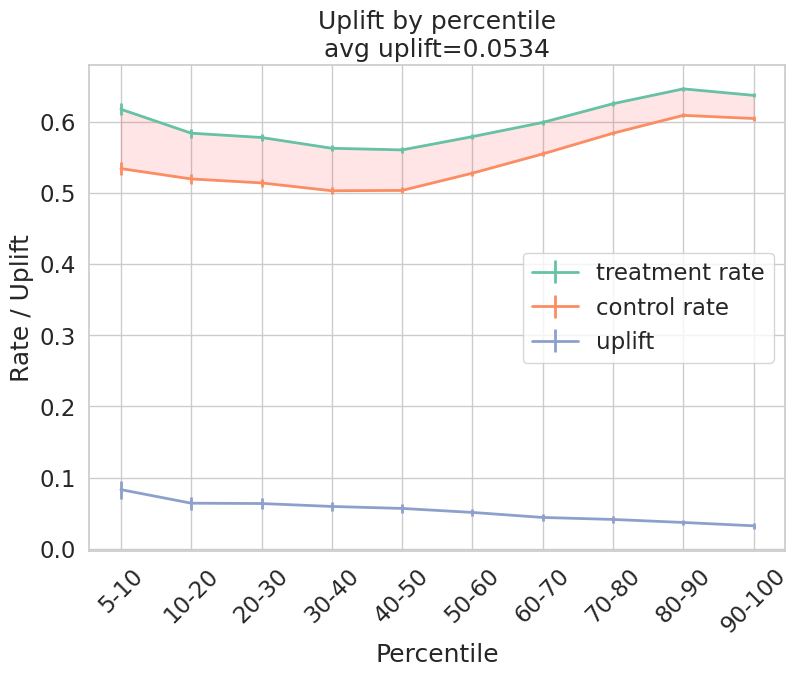

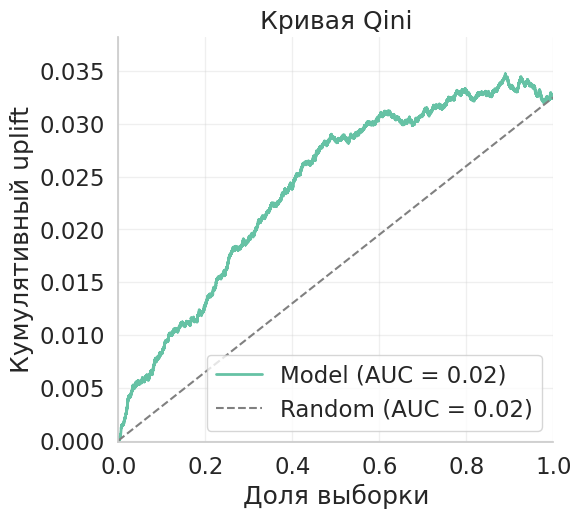

T-lerner


<Figure size 500x500 with 0 Axes>

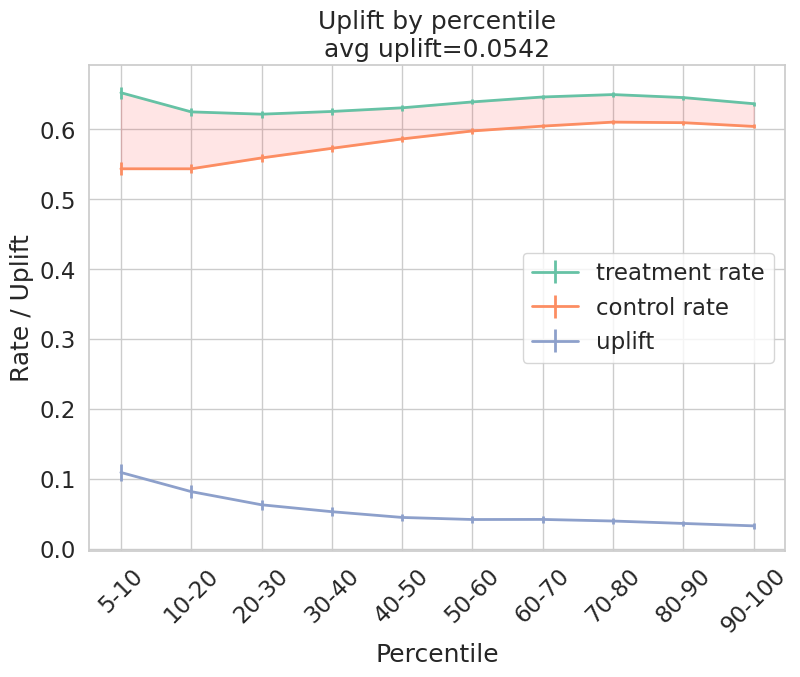

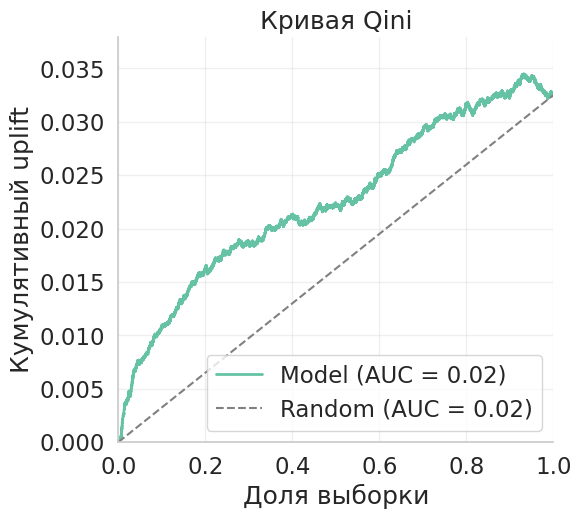

X-lerner


<Figure size 500x500 with 0 Axes>

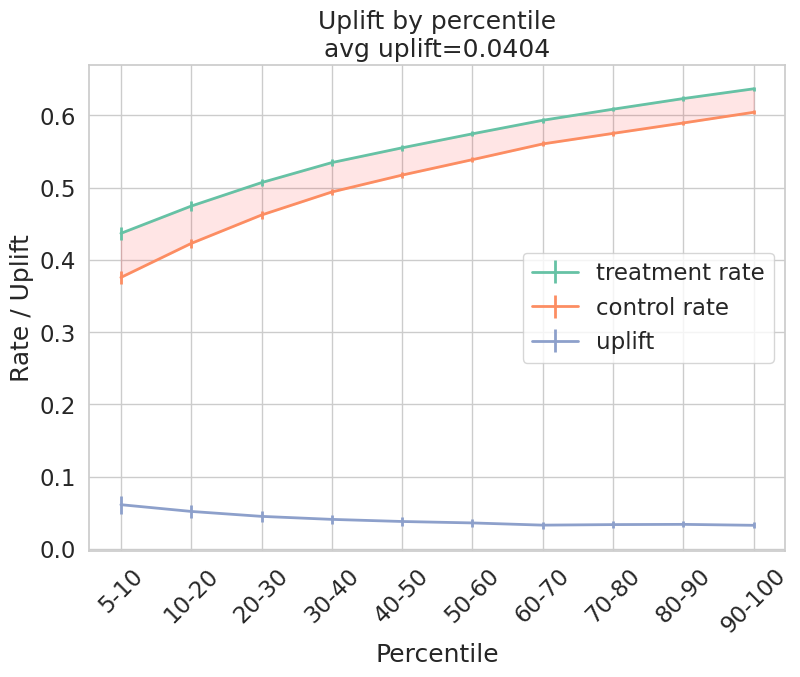

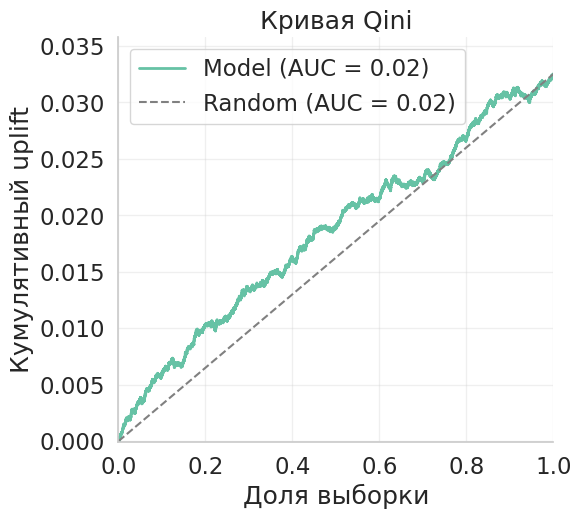

R-lerner


<Figure size 500x500 with 0 Axes>

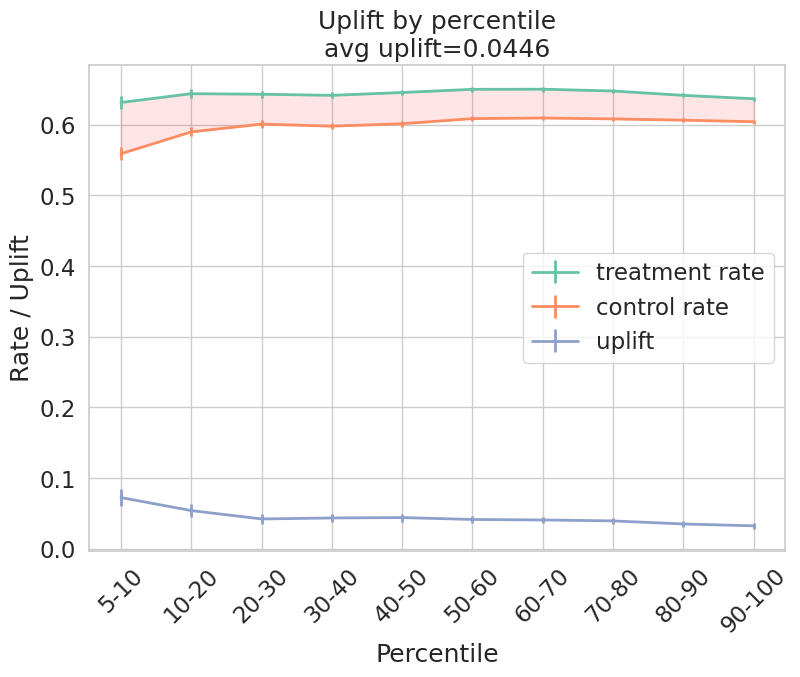

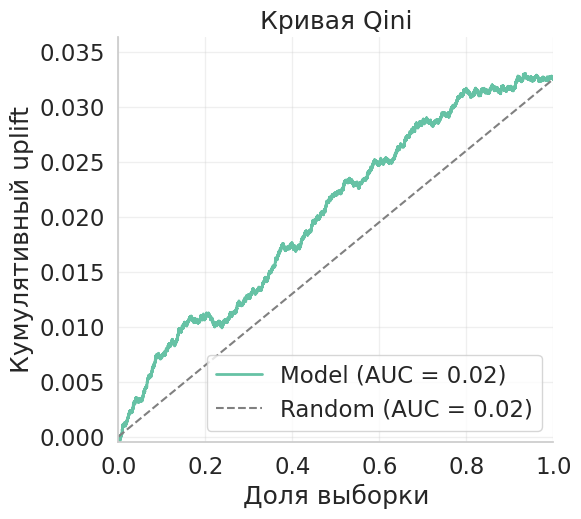

Transformation target


<Figure size 500x500 with 0 Axes>

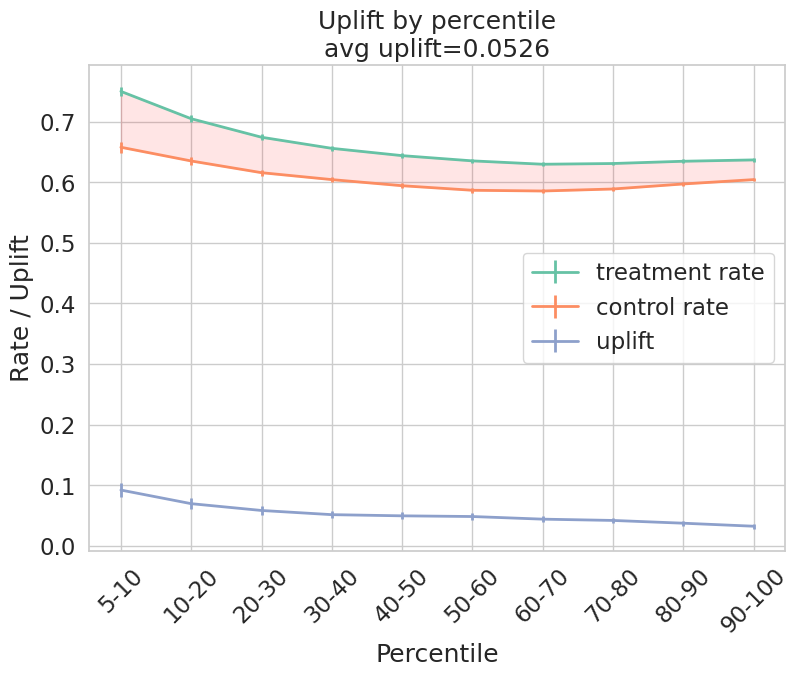

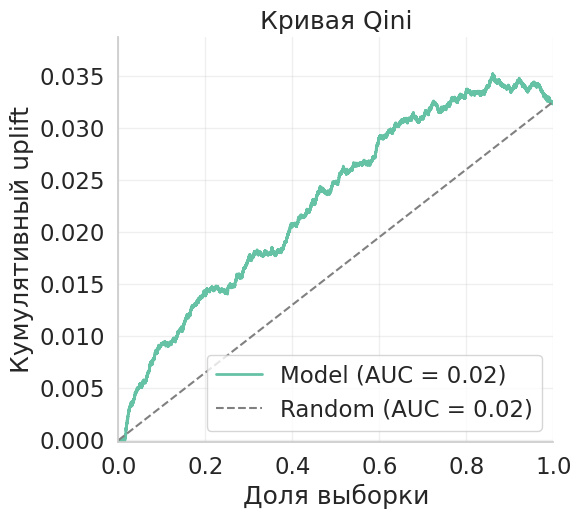

MultiClass


<Figure size 500x500 with 0 Axes>

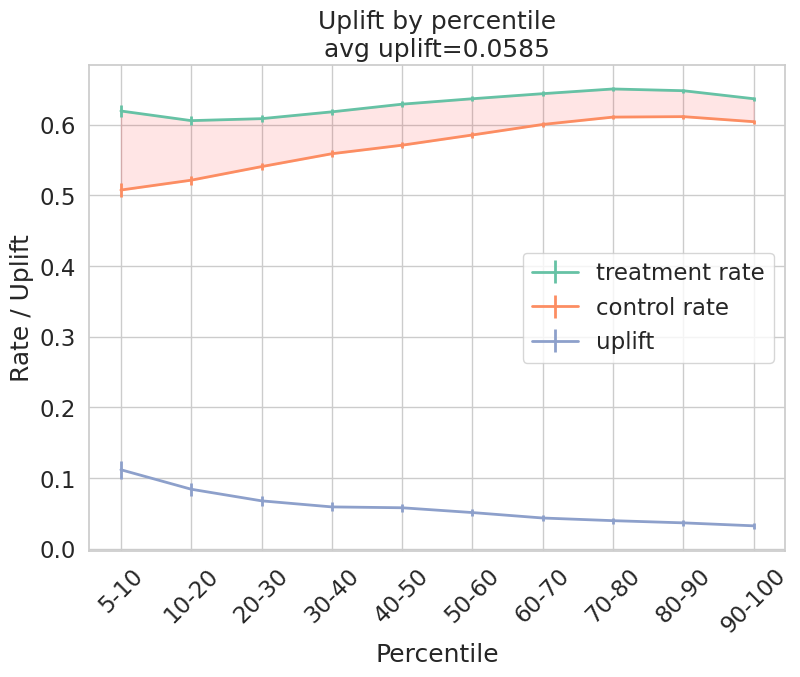

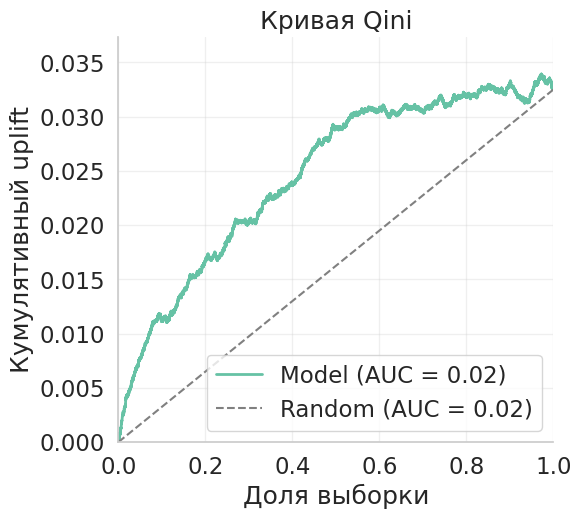

DragonNet


<Figure size 500x500 with 0 Axes>

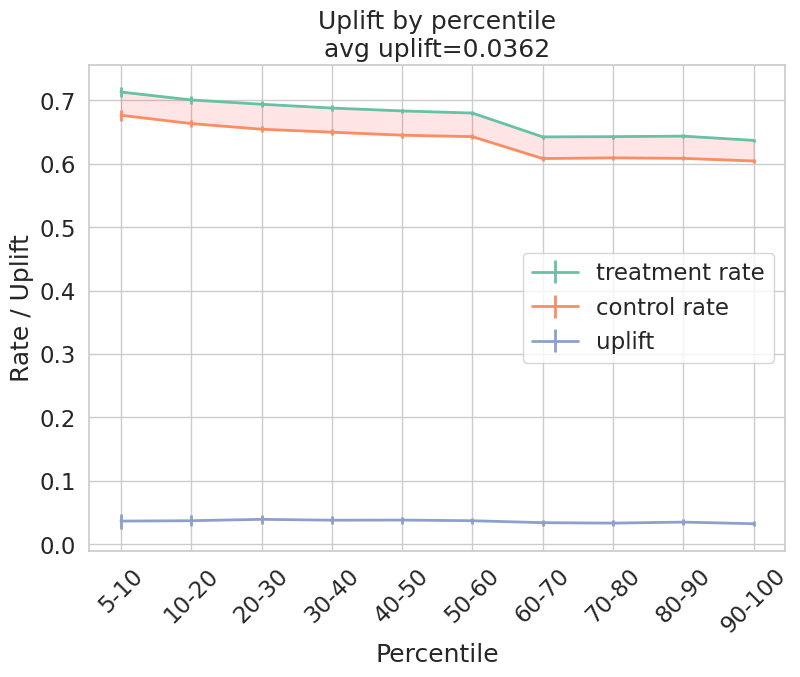

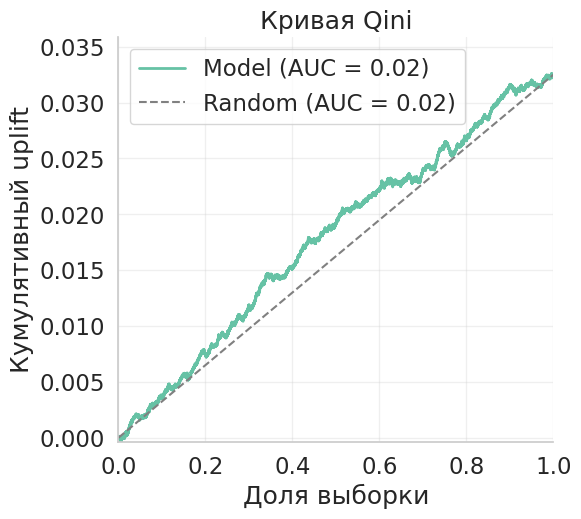

In [ ]:
# Приведение к numpy
y_val = np.array(y_val)
treat_val = np.array(treat_val)
uplifts = [np.array(u) for u in uplifts]

# Хранилище для uplift@30
results = []

for name, uplift in zip(names, uplifts):
    # uplift@30
    score = uplift_at_k(y_true=y_val, uplift=uplift, treatment=treat_val,
                        strategy='by_group', k=0.3)
    results.append({'model': name, 'uplift@30': score})

    # Печать имени модели перед графиками
    print(name)

    # Построение графиков
    plt.figure(figsize=(5, 5))
    plot_uplift_by_percentile(y_val, uplift, treat_val, strategy='overall', kind='line')
    plt.show()
    
    plt.figure(figsize=(5, 5))    
    plot_qini_curve(y_val, uplift, treat_val, perfect=False)
    plt.show()

# DataFrame с результатами uplift@30
df_uplift_at_30 = pd.DataFrame(results)

In [ ]:
df_uplift_at_30

,model,uplift@30
0,S-lerner,0.064638
1,T-lerner,0.061449
2,X-lerner,0.045182
3,R-lerner,0.042409
4,Transformation target,0.059980
5,MultiClass,0.064364
6,DragonNet,0.038037


Для выбранной модели постройте гистограммы предсказаний потенциальных исходов (если модель это позволяет) и значений uplift (или оценок CATE). Постройте также графики `plot_uplift_by_percentile`.

Возьмем S-lerner

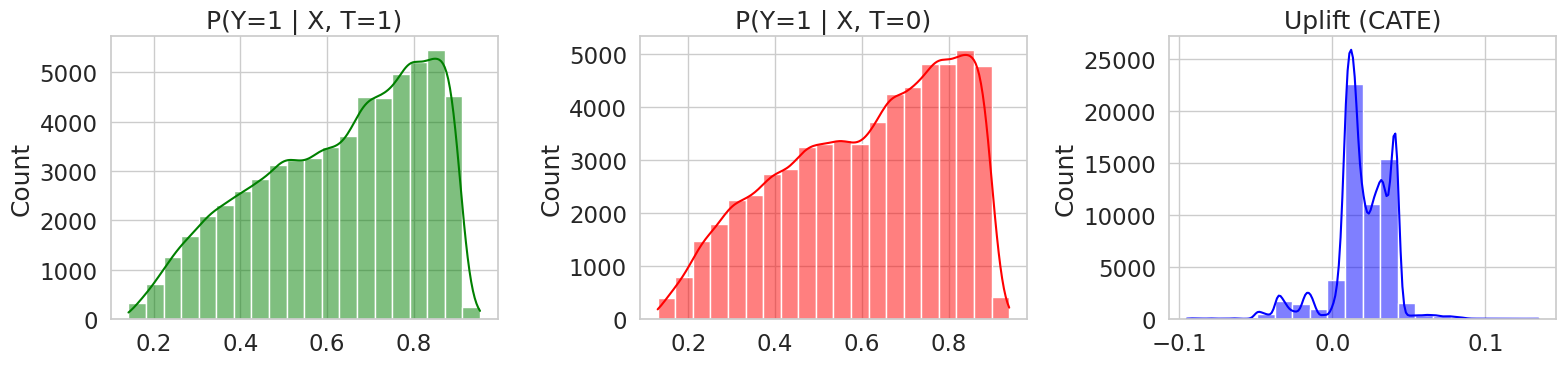

In [ ]:
# 1) Восстановим DataFrame для валидации, с правильным именем столбца
X_val_df = df_features.loc[indices_valid].copy()
X_val_df['treatment'] = treat_val  # было treatment_flg, но в SoloModel это 'treatment'

# 2) Сконструируем два DataFrame-а – под лечение и контроль
X_t_df = X_val_df.copy()
X_t_df['treatment'] = 1
X_c_df = X_val_df.copy()
X_c_df['treatment'] = 0

# 3) Предсказания вероятностей
clf = sm.estimator  # ваш CatBoostClassifier из SoloModel

proba_treated = clf.predict_proba(X_t_df)[:, 1]   # P(Y=1 | X, T=1)
proba_control = clf.predict_proba(X_c_df)[:, 1]   # P(Y=1 | X, T=0)
cate          = proba_treated - proba_control     # CATE (uplift)

# 4) Гистограммы
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
sns.histplot(proba_treated, kde=True, bins=20, color='green')
plt.title("P(Y=1 | X, T=1)")

plt.subplot(1, 3, 2)
sns.histplot(proba_control, kde=True, bins=20, color='red')
plt.title("P(Y=1 | X, T=0)")

plt.subplot(1, 3, 3)
sns.histplot(cate, kde=True, bins=20, color='blue')
plt.title("Uplift (CATE)")

plt.tight_layout()
plt.show()

In [ ]:
def plot_uplift_by_percentile(y_true, treat, uplift_scores, bins=10):
    df = pd.DataFrame({
        'y': y_true,
        'treatment': treat,
        'uplift_score': uplift_scores
    })

    df['percentile'] = pd.qcut(df['uplift_score'], q=bins, labels=False, duplicates='drop')
    grouped = df.groupby('percentile')

    avg_uplift = []
    for _, g in grouped:
        y_treat = g[g['treatment'] == 1]['y']
        y_control = g[g['treatment'] == 0]['y']
        if len(y_treat) > 0 and len(y_control) > 0:
            uplift = y_treat.mean() - y_control.mean()
            avg_uplift.append(uplift)
        else:
            avg_uplift.append(0)

    plt.figure(figsize=(8, 5))
    plt.bar(range(len(avg_uplift)), avg_uplift)
    plt.xlabel('Uplift Score Percentile')
    plt.ylabel('Observed uplift (Y₁ - Y₀)')
    plt.title('Uplift by Model Score Percentile')
    plt.show()

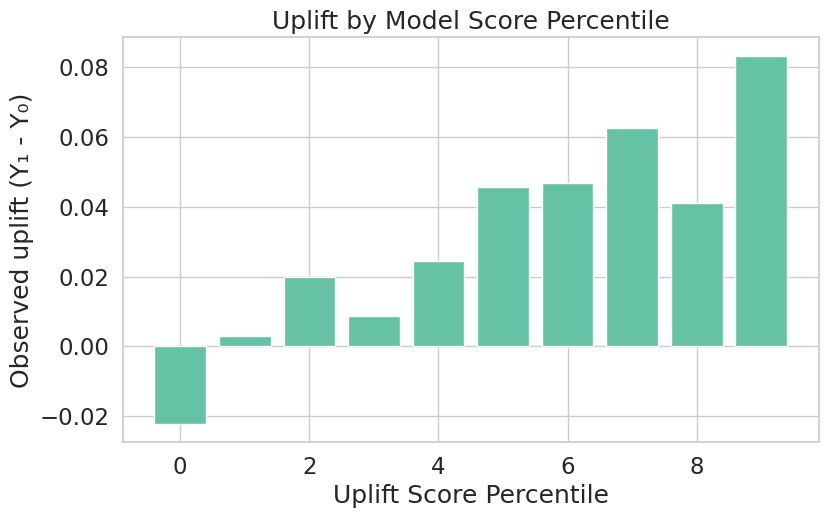

In [ ]:
plot_uplift_by_percentile(y_val, treat_val, uplift_sm)

Сделайте выводы.